In [ ]:
import torch # for all things PyTorch
import torch.nn as nn # for torch.nn.Module, the parent object for PyTorch models
import torch.nn.functional as F # for the activation function

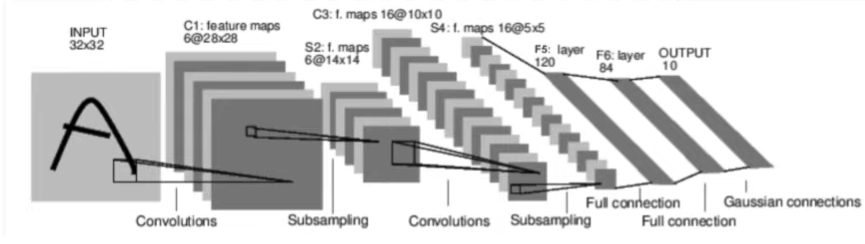
Above is diagram of LeNet-5, earliest conulational neural nets. It reads small images of handwritten letters, and correctly classifies which digit was presented in the image.

Convolutional layer: Scans input for patterns. Has a feature map that highlights where verything is.    

Abridged verison:
C1, scans input, for features learned during trianing. ouputs a mapto where it each saw learned features in image. This "activation map" is downsampled in layer S2. 

C3, another convolutional layer that scans C1's activation map for combinations of features. It also puts out an activation map describing the spatial locations of these feature combinations, which is downsampled in layer S4.

Finally, the fully connected layers at the end, F5, F6, and OUTPUT are a classifier that takes the final activation map, and classifies it into one of ten bins representing 10 digits


In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black and white), 6 output channels, 3x3 square convolution
        # kernel
        self.conv1= nn.Conv2d(1, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16*6*6, 120) # 6*6 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    def num_flat_features(self, x):
        size = x.size()[1:] # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

nn.module means LeNet inherits everything a PyTorch neural network needs, like tracking weights, saving/loading the model, and making .backward() work. You always need it

self.conv(maps, feature maps, filter) first takes the inputs of how many maps, then makes feature maps with the filter. 

self.fc(feature maps, neurons) taks the neurons and makes fewer ones, finally reaching 10 for the number of bins. 

3*3 means learnable weights. Model comes up them itself to find useful stuff.

linearize ithe stuff using nn.Linear. 

Forward Pass: 
.conv1 runs the first conv filter across the image to detect simple patterns
F.relu only keeps positive signals, 2x2 only takes max value of each box
Second conv layer does the same thing
Flattens the feature, and then the relu makes it one of the 10 digit scores.

numflat features gets total number

Model will have __init__() function. instantiates its layers, loads any data artifacts it might need, NLP model might load vocab
Model will have a forward() function. This is where the actual computation happens: An input is passed though the network layers and various functions to generate output.
Other than that, you can build out your model class like any Python class, adding whatever properties and methods you need to support your model's computation.
you can build your model class like any other Python class, whatever properties and methods you need to support your model's computation.

In [ ]:
net = LeNet()
print(net)

inputs = torch.randn(1, 1, 32, 32)
print("\n image batch shape:")
print(input.shape)

output = net(inputs)
print("\n output shape:")
print(output)
print(output.shape)

LeNet class and print the net object. Subclass will report the layers it has created and their shapes and parameters. This can show overview of a model.

We create a dummy input representing 32x32 image with 1 color channel. Normall you would load image tile and convert to tensor. 

Extra dimension to our tensor, the batch dimension. PyTorch assume we are working on batches of data. bath of 16 would have shape (16,1,32,32). since we only using one image, make (1,1,32,32)

Ask model fo rinference by calling it like a function. The output of this call represents the models confidence that the input represets a digit. Since this model hasn't learned anything yet, we shouldn't expect any signal. Looking at the shape of output, we can see it also has a batch dimension, the siez of which should always match the input batch dimension. If we had passed batch of 16 instances, output would have shape of (16, 10)